# 04 — Machine Learning : Scoring d'alerte Early Warning

## Objectif du notebook

Ce notebook constitue la phase de **Machine Learning** après la validation du Feature Engineering et l'analyse exploratoire.

La question étudiée est :

> **Peut-on utiliser les informations disponibles à l'année T pour estimer le risque qu'un corridor origine → pays d'asile connaisse une hausse significative des demandes d'asile à T+1 ?**

Le parcours est volontairement simple et progressif :

1. contrôler les données et construire correctement le label ;
2. vérifier le déséquilibre des classes ;
3. effectuer un **split chronologique** Train / Validation / Test ;
4. préparer les features sans fuite de données ;
5. entraîner **4 modèles de départ sans tuning** ;
6. comparer les modèles sur la **Validation uniquement** ;
7. sélectionner les **2 meilleurs modèles apprenants** ;
8. optimiser uniquement ces deux modèles avec une validation croisée temporelle ;
9. choisir le modèle final et le seuil sur la Validation ;
10. ouvrir le **Test une seule fois** pour l'évaluation finale ;
11. analyser l'importance des features et revenir sur les hypothèses H1–H5.

### Principe essentiel

Le jeu de Test ne participe **ni au choix du modèle, ni au tuning, ni au choix du seuil**.

In [7]:
# ============================================================
# 0. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    balanced_accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve
)

from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

import joblib

pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

## 1. Charger le dataset issu du Feature Engineering

Nous utilisons uniquement le dataset dont les features ont déjà été validées.

À ce stade, nous **ne recréons pas le Feature Engineering** : le but est de vérifier que le fichier possède les colonnes attendues et que sa granularité reste bien :

**un corridor (`coo_id`, `coa_id`) × une année (`year`)**.

In [8]:
DATA_PATH = "../data/feature_engineering_outputs/dataset_ml_features.csv"

df = pd.read_csv(DATA_PATH)

print("Dimensions du dataset :", df.shape)
print("Période :", int(df["year"].min()), "à", int(df["year"].max()))
display(df.head())

Dimensions du dataset : (86234, 20)
Période : 2000 à 2025


,year,coo_id,coa_id,coa_name,coo_name,origin_region,asylum_region,applied,applied_lag1,applied_lag2,growth_past_1,absolute_change_past_1,acceleration,two_consecutive_increases,origin_applied_total_t,asylum_applied_total_t,segment_share_origin_t,segment_share_asylum_t,idmc_total_origin_lag1,applied_t1
0,2019,10,109,Lebanon,Armenia,WESTERN ASIA,WESTERN ASIA,5,NaN,NaN,NaN,NaN,NaN,NaN,6766,3610,0.000739,0.001385,NaN,0.0
1,2021,10,109,Lebanon,Armenia,WESTERN ASIA,WESTERN ASIA,5,NaN,5.0,NaN,NaN,NaN,NaN,5573,1141,0.000897,0.004382,800.0,10.0
2,2022,10,109,Lebanon,Armenia,WESTERN ASIA,WESTERN ASIA,10,5.0,NaN,1.000000,5.0,NaN,NaN,11096,2154,0.000901,0.004643,800.0,0.0
3,2000,10,11,Australia,Armenia,WESTERN ASIA,AUSTRALIA-NEW ZEALAND,19,NaN,NaN,NaN,NaN,NaN,NaN,10722,19541,0.001772,0.000972,NaN,10.0
4,2001,10,11,Australia,Armenia,WESTERN ASIA,AUSTRALIA-NEW ZEALAND,10,19.0,NaN,-0.473684,-9.0,NaN,NaN,11838,18067,0.000845,0.000553,NaN,10.0


## 2. Contrôles préalables avant la modélisation

Avant de créer la cible, nous vérifions :

- la présence des colonnes indispensables ;
- l'absence de doublons corridor–année ;
- la validité de `applied` ;
- la disponibilité de `applied_t1`.

Ces contrôles évitent de commencer un entraînement sur un dataset mal structuré.

In [9]:
required_columns = [
    "year", "coo_name", "coa_name",
    "applied", "applied_t1",
    "applied_lag1", "applied_lag2",
    "growth_past_1", "absolute_change_past_1",
    "acceleration", "two_consecutive_increases",
    "origin_applied_total_t", "asylum_applied_total_t",
    "segment_share_origin_t", "segment_share_asylum_t",
    "origin_region", "asylum_region",
    "idmc_total_origin_lag1"
]

missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f"Colonnes manquantes : {missing_columns}")

duplicates = df.duplicated(subset=["coo_id", "coa_id", "year"]).sum()
negative_applied = (df["applied"] < 0).sum()
missing_applied = df["applied"].isna().sum()

print("Doublons corridor-année :", duplicates)
print("Valeurs négatives de applied :", negative_applied)
print("Valeurs manquantes de applied :", missing_applied)
print("Valeurs manquantes de applied_t1 :", df["applied_t1"].isna().sum())

if duplicates > 0:
    raise ValueError("Des doublons corridor-année doivent être corrigés avant le ML.")

Doublons corridor-année : 0
Valeurs négatives de applied : 0
Valeurs manquantes de applied : 0
Valeurs manquantes de applied_t1 : 3967


## 3. Étape 1 — Construire correctement le label

### Règle métier

Une observation est considérée comme une **escalade à T+1** lorsque les deux conditions sont satisfaites :

- augmentation relative d'au moins **30 %** ;
- augmentation absolue d'au moins **100 demandes**.

Ainsi :

```text
target_escalade = 1
si applied_t1 >= applied × 1,30
ET applied_t1 - applied >= 100
```

### Attention à 2025

Si `applied_t1` est absent, le label doit rester **NaN**.  
Une année sans T+1 observable n'est pas équivalente à une absence d'escalade.

`absolute_change_t1` est créé uniquement pour construire le label. Cette variable est **future** et sera interdite dans les features.

In [10]:
# Variable future utilisée uniquement pour construire le label.
df["absolute_change_t1"] = df["applied_t1"] - df["applied"]

df["target_escalade"] = np.where(
    df["applied_t1"].isna(),
    np.nan,
    (
        (df["applied_t1"] >= df["applied"] * 1.30)
        & (df["absolute_change_t1"] >= 100)
    ).astype(int)
)

# Dataset utilisable pour l'apprentissage supervisé.
labeled = df[df["target_escalade"].notna()].copy()
labeled["target_escalade"] = labeled["target_escalade"].astype(int)

print("Observations totales :", len(df))
print("Observations labellisées :", len(labeled))
print("Observations sans label T+1 :", df["target_escalade"].isna().sum())

display(
    labeled["target_escalade"]
    .value_counts()
    .rename(index={0: "0 - Pas d'escalade", 1: "1 - Escalade"})
    .to_frame("Nombre")
)

Observations totales : 86234
Observations labellisées : 82267
Observations sans label T+1 : 3967


,Nombre
target_escalade,
0 - Pas d'escalade,75800
1 - Escalade,6467


## 4. Étape 2 — Mesurer le déséquilibre de la cible

L'EDA a montré que la classe `1` est minoritaire. Nous le recalculons ici car le traitement du déséquilibre doit être fondé sur les données effectivement utilisées pour le ML.

### Pourquoi l'accuracy n'est-elle pas notre métrique principale ?

Si environ 92 % des observations appartiennent à la classe 0, un modèle qui prédit presque toujours 0 peut afficher une accuracy élevée tout en étant inutile pour un système d'alerte.

Nous utiliserons donc principalement :

- **Recall** : parmi les vraies escalades, combien sont détectées ?
- **Precision** : parmi les alertes émises, combien sont réellement des escalades ?
- **F1-score** : compromis Precision / Recall ;
- **PR-AUC** : qualité globale du classement de la classe rare — **métrique principale de comparaison** ;
- **ROC-AUC** : métrique complémentaire ;
- **Balanced Accuracy** : donne le même poids aux deux classes ;
- **matrice de confusion** : visualise faux positifs et faux négatifs.

Dans un Early Warning, les faux négatifs peuvent être particulièrement importants : une escalade réelle non détectée peut empêcher une anticipation. Le coût métier exact devra toutefois être validé avec les utilisateurs.

In [11]:
target_counts = labeled["target_escalade"].value_counts().sort_index()
target_pct = labeled["target_escalade"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Nombre": target_counts,
    "Part (%)": target_pct
}).rename(index={0: "Pas d'escalade", 1: "Escalade"})

display(target_summary.round(2))

,Nombre,Part (%)
target_escalade,,
Pas d'escalade,75800,92.14
Escalade,6467,7.86


## 5. Split chronologique Train / Validation / Test

Le problème est temporel : nous utilisons le passé pour anticiper une année future.

Nous ne faisons donc **pas de split aléatoire**.

- **Train : 2000–2018** → apprentissage des modèles ;
- **Validation : 2019–2021** → comparaison, choix des modèles et du seuil ;
- **Test : 2022–2024** → évaluation finale uniquement ;
- **2025** → non labellisé car T+1 n'est pas disponible.

Cette séparation reproduit mieux la situation réelle : entraîner un modèle sur le passé puis l'appliquer à des années plus récentes.

In [12]:
train = labeled[labeled["year"] <= 2018].copy()
validation = labeled[labeled["year"].between(2019, 2021)].copy()
test = labeled[labeled["year"].between(2022, 2024)].copy()

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Période": ["2000–2018", "2019–2021", "2022–2024"],
    "Nombre": [len(train), len(validation), len(test)],
    "Taux escalade (%)": [
        train["target_escalade"].mean() * 100,
        validation["target_escalade"].mean() * 100,
        test["target_escalade"].mean() * 100
    ]
})

display(split_summary.round(2))

# Contrôles temporels simples.
assert train["year"].max() < validation["year"].min()
assert validation["year"].max() < test["year"].min()
print("Contrôle temporel : OK")

,Split,Période,Nombre,Taux escalade (%)
0,Train,2000–2018,59649,7.45
1,Validation,2019–2021,10564,9.35
2,Test,2022–2024,12054,8.60


Contrôle temporel : OK


## 6. Définir les features et contrôler le target leakage

Nous utilisons uniquement des informations disponibles à **T ou avant T**.

### Variables interdites

- `applied_t1` : information de T+1 ;
- `absolute_change_t1` : calculée avec T+1 ;
- `target_escalade` : cible à prédire.

Les identifiants `coo_id` et `coa_id` sont des **catégories**, pas des quantités. Une différence numérique entre deux identifiants n'a aucune signification métier : ils seront donc encodés comme variables catégorielles.

`year` est conservée comme information temporelle. Son utilité devra être contrôlée dans l'analyse d'importance.

In [13]:
FEATURES = [
    "applied",
    "applied_lag1",
    "applied_lag2",
    "growth_past_1",
    "absolute_change_past_1",
    "acceleration",
    "two_consecutive_increases",
    "origin_applied_total_t",
    "asylum_applied_total_t",
    "segment_share_origin_t",
    "segment_share_asylum_t",
    "coo_name",
    "coa_name",
    "origin_region",
    "asylum_region",
    "year",
    "idmc_total_origin_lag1",
]

TARGET = "target_escalade"

forbidden_features = {
    "applied_t1",
    "absolute_change_t1",
    "target_escalade",
}

leakage_found = forbidden_features.intersection(FEATURES)
if leakage_found:
    raise ValueError(f"Risque de target leakage : {leakage_found}")

print("Contrôle anti-fuite : OK")
print("Nombre de features :", len(FEATURES))

X_train = train[FEATURES].copy()
y_train = train[TARGET].copy()

X_val = validation[FEATURES].copy()
y_val = validation[TARGET].copy()

# Le Test est préparé mais ne sera utilisé qu'à la fin.
X_test = test[FEATURES].copy()
y_test = test[TARGET].copy()

Contrôle anti-fuite : OK
Nombre de features : 17


## 7. Valeurs manquantes et prétraitement

Les variables historiques présentent des valeurs manquantes. Nous ne supprimons pas automatiquement ces lignes.

### Variables numériques

- imputation par la **médiane du Train** ;
- ajout d'indicateurs de valeurs manquantes ;
- standardisation pour rendre la Régression Logistique plus stable.

### Variables catégorielles

- remplacement des valeurs manquantes par `MISSING` ;
- One-Hot Encoding ;
- `handle_unknown="ignore"` permet d'accepter en Validation/Test une catégorie absente du Train.

Toutes les transformations sont intégrées dans un `Pipeline`. Elles sont donc apprises **uniquement à partir du Train**, ce qui évite une fuite d'information.

Le cas IDMC reste volontairement visible : l'imputation ne signifie pas qu'une valeur manquante vaut réellement la médiane. L'importance de cette feature sera analysée plus tard.

In [14]:
categorical_features = [
    "coo_name", "coa_name",
    "origin_region", "asylum_region"
]

numeric_features = [
    c for c in FEATURES if c not in categorical_features
]

# Pour assurer un traitement catégoriel explicite et stable.
for col in categorical_features:
    X_train[col] = X_train[col].astype("string")
    X_val[col] = X_val[col].astype("string")
    X_test[col] = X_test[col].astype("string")

missing_train = (
    X_train.isna().mean().mul(100)
    .sort_values(ascending=False)
    .rename("Missing Train (%)")
    .to_frame()
)

display(missing_train[missing_train["Missing Train (%)"] > 0].round(2))

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_preprocessor, numeric_features),
    ("cat", categorical_preprocessor, categorical_features)
])

,Missing Train (%)
idmc_total_origin_lag1,71.68
acceleration,36.22
two_consecutive_increases,36.22
applied_lag2,30.97
growth_past_1,23.77
absolute_change_past_1,23.77
applied_lag1,23.77


## 8. Gérer le déséquilibre des classes

Nous privilégions ici une stratégie simple : **pondérer davantage la classe minoritaire**.

Pourquoi ne pas utiliser SMOTE immédiatement ?

Parce que le projet est temporel et que notre objectif est d'abord d'obtenir des baselines propres et interprétables. Une génération artificielle d'observations ajouterait une étape supplémentaire qui n'est pas nécessaire pour cette première comparaison.

- Régression Logistique : `class_weight="balanced"` ;
- Random Forest : `class_weight="balanced"` ;
- XGBoost : `scale_pos_weight = nombre de 0 / nombre de 1`, calculé **sur le Train uniquement**.

La Dummy Baseline reste volontairement naïve : elle sert de point de comparaison.

In [15]:
train_class_counts = y_train.value_counts().sort_index()

n_negative = int((y_train == 0).sum())
n_positive = int((y_train == 1).sum())

scale_pos_weight = n_negative / n_positive

print("Classe 0 dans Train :", n_negative)
print("Classe 1 dans Train :", n_positive)
print("Taux positif Train :", round(y_train.mean() * 100, 2), "%")
print("scale_pos_weight pour XGBoost :", round(scale_pos_weight, 2))

Classe 0 dans Train : 55207
Classe 1 dans Train : 4442
Taux positif Train : 7.45 %
scale_pos_weight pour XGBoost : 12.43


# 9. Entraîner les 4 modèles de départ

À cette étape, **aucune optimisation lourde**.

Nous voulons d'abord savoir quelles familles de modèles semblent adaptées au problème.

Les quatre modèles comparés sont :

1. **Dummy Classifier** — baseline naïve ;
2. **Régression Logistique** — modèle linéaire et interprétable ;
3. **Random Forest** — modèle d'arbres capable de relations non linéaires ;
4. **XGBoost** — boosting d'arbres capable de représenter des interactions plus complexes.

Les paramètres sont raisonnables et volontairement limités. Le tuning ne viendra qu'après la comparaison sur Validation.

### 9.1 Modèle 1 — Dummy Classifier

In [16]:
baseline_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DummyClassifier(strategy="prior", random_state=RANDOM_STATE))
])

baseline_model.fit(X_train, y_train)
val_proba_baseline = baseline_model.predict_proba(X_val)[:, 1]

### 9.2 Modèle 2 — Régression Logistique

In [17]:
logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)
val_proba_logistic = logistic_model.predict_proba(X_val)[:, 1]

### 9.3 Modèle 3 — Random Forest

In [18]:
rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
val_proba_rf = rf_model.predict_proba(X_val)[:, 1]

### 9.4 Modèle 4 — XGBoost

In [19]:
xgb_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)
val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

## 10. Comparer les 4 modèles sur la Validation

La comparaison se fait sur **2019–2021**.

### Métrique principale : PR-AUC

La PR-AUC est prioritaire car la classe positive est rare et qu'elle évalue la qualité du classement des alertes sans imposer un seuil particulier.

Les métriques dépendantes d'un seuil (`Recall`, `Precision`, `F1`, `Balanced Accuracy`) sont d'abord calculées avec **0,50** uniquement comme seuil de référence.

Le seuil métier sera étudié plus tard et uniquement sur la Validation.

In [20]:
def evaluate_model(name, y_true, proba, threshold=0.50):
    pred = (proba >= threshold).astype(int)

    return {
        "Modèle": name,
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "PR-AUC": average_precision_score(y_true, proba),
        "ROC-AUC": roc_auc_score(y_true, proba),
        "Balanced Accuracy": balanced_accuracy_score(y_true, pred)
    }

validation_probas = {
    "Dummy Baseline": val_proba_baseline,
    "Régression logistique": val_proba_logistic,
    "Random Forest": val_proba_rf,
    "XGBoost": val_proba_xgb
}

validation_results = pd.DataFrame([
    evaluate_model(name, y_val, proba)
    for name, proba in validation_probas.items()
]).sort_values("PR-AUC", ascending=False).reset_index(drop=True)

display(validation_results.round(3))

,Modèle,Precision,Recall,F1,PR-AUC,ROC-AUC,Balanced Accuracy
0,Random Forest,0.237,0.827,0.368,0.259,0.826,0.776
1,XGBoost,0.241,0.790,0.369,0.257,0.820,0.767
2,Régression logistique,0.184,0.684,0.290,0.193,0.741,0.686
3,Dummy Baseline,0.000,0.000,0.000,0.094,0.500,0.500


### 10.1 Visualiser les matrices de confusion

La matrice de confusion permet de traduire les métriques en nombres d'observations :

- **vrai positif** : escalade correctement détectée ;
- **faux négatif** : escalade manquée ;
- **faux positif** : alerte émise à tort ;
- **vrai négatif** : absence d'escalade correctement reconnue.

À ce stade, les matrices utilisent encore le seuil de référence 0,50.

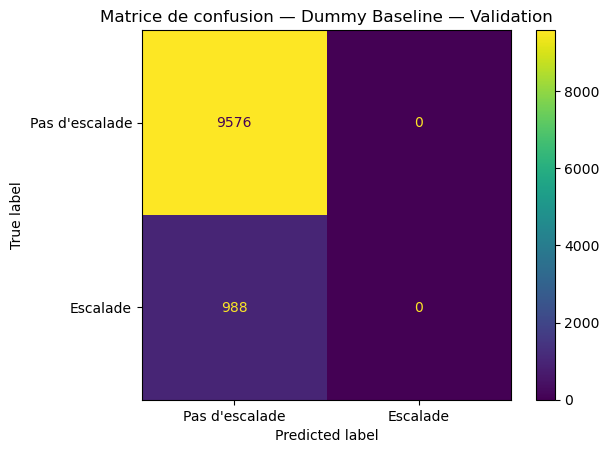

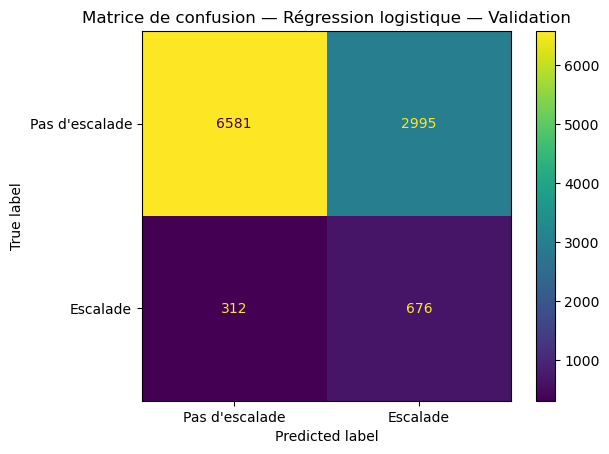

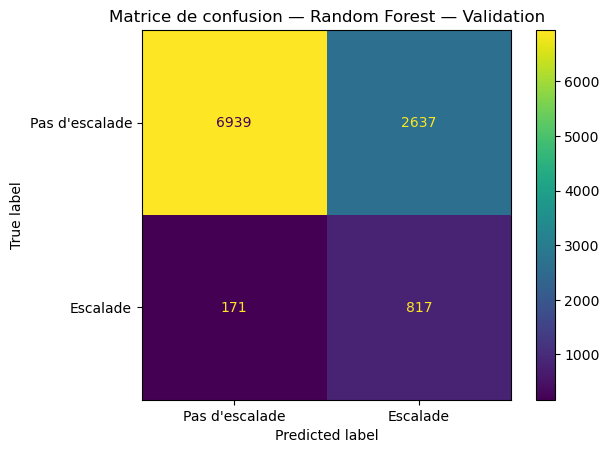

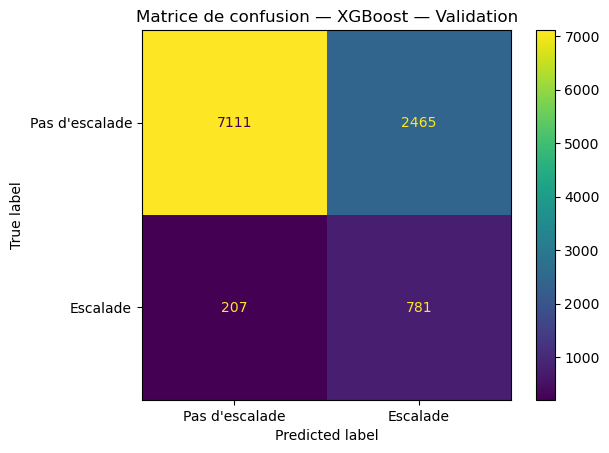

In [21]:
for name, proba in validation_probas.items():
    pred = (proba >= 0.50).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_val,
        pred,
        display_labels=["Pas d'escalade", "Escalade"],
        values_format="d"
    )
    plt.title(f"Matrice de confusion — {name} — Validation")
    plt.show()

## 11. Sélectionner les 2 meilleurs modèles

La Dummy Baseline est indispensable pour vérifier que les modèles apprennent réellement un signal, mais elle n'est pas candidate au tuning.

Nous sélectionnons donc les **deux meilleurs modèles apprenants selon la PR-AUC sur Validation** parmi :

- Régression Logistique ;
- Random Forest ;
- XGBoost.

Cette sélection est faite **avant toute optimisation**.

In [22]:
candidate_names = [
    "Régression logistique",
    "Random Forest",
    "XGBoost"
]

candidate_results = (
    validation_results[
        validation_results["Modèle"].isin(candidate_names)
    ]
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

top2_models = candidate_results.head(2)["Modèle"].tolist()

display(candidate_results.round(3))
print("Deux modèles retenus pour l'optimisation :", top2_models)

,Modèle,Precision,Recall,F1,PR-AUC,ROC-AUC,Balanced Accuracy
0,Random Forest,0.237,0.827,0.368,0.259,0.826,0.776
1,XGBoost,0.241,0.790,0.369,0.257,0.820,0.767
2,Régression logistique,0.184,0.684,0.290,0.193,0.741,0.686


Deux modèles retenus pour l'optimisation : ['Random Forest', 'XGBoost']


# 12. Optimiser uniquement les 2 meilleurs modèles

## Pourquoi une validation croisée temporelle ?

Une validation croisée aléatoire mélangerait des observations anciennes et futures.

Nous utilisons donc des folds temporels **expansifs** à l'intérieur du Train :

- Fold 1 : entraînement jusqu'en 2012 → validation 2013–2014 ;
- Fold 2 : entraînement jusqu'en 2014 → validation 2015–2016 ;
- Fold 3 : entraînement jusqu'en 2016 → validation 2017–2018.

La Validation externe 2019–2021 reste donc totalement indépendante du tuning.

### Pourquoi un tuning léger ?

L'objectif pédagogique n'est pas de tester des centaines de combinaisons, mais de vérifier si quelques hyperparamètres importants améliorent réellement les deux meilleurs modèles.

In [23]:
# Construction de folds temporels personnalisés.
years_train = train["year"].to_numpy()

temporal_periods = [
    (2012, 2013, 2014),
    (2014, 2015, 2016),
    (2016, 2017, 2018),
]

temporal_cv = []

for train_end, val_start, val_end in temporal_periods:
    train_idx = np.where(years_train <= train_end)[0]
    val_idx = np.where(
        (years_train >= val_start) & (years_train <= val_end)
    )[0]

    temporal_cv.append((train_idx, val_idx))

    print(
        f"Train <= {train_end}: {len(train_idx):,} lignes | "
        f"Validation {val_start}-{val_end}: {len(val_idx):,} lignes"
    )

Train <= 2012: 37,972 lignes | Validation 2013-2014: 6,954 lignes
Train <= 2014: 44,926 lignes | Validation 2015-2016: 7,182 lignes
Train <= 2016: 52,108 lignes | Validation 2017-2018: 7,541 lignes


### 12.1 Espaces d'hyperparamètres

Chaque grille reste volontairement petite.

La fonction `GridSearchCV` utilise `average_precision`, c'est-à-dire la **PR-AUC**, comme critère de sélection.

In [24]:
model_objects = {
    "Régression logistique": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

param_grids = {
    "Régression logistique": {
        "model__C": [0.1, 1.0, 10.0]
    },

    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [8, 15, None],
        "model__min_samples_leaf": [5, 10]
    },

    "XGBoost": {
        "model__n_estimators": [150, 300],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.03, 0.08]
    }
}

tuned_models = {}
tuning_summary = []

for model_name in top2_models:
    print("\n" + "=" * 70)
    print("Optimisation :", model_name)

    search = GridSearchCV(
        estimator=model_objects[model_name],
        param_grid=param_grids[model_name],
        scoring="average_precision",
        cv=temporal_cv,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    search.fit(X_train, y_train)

    tuned_models[model_name] = search.best_estimator_

    tuning_summary.append({
        "Modèle": model_name,
        "Meilleure PR-AUC CV Train": search.best_score_,
        "Meilleurs paramètres": search.best_params_
    })

display(pd.DataFrame(tuning_summary))


Optimisation : Random Forest
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Optimisation : XGBoost
Fitting 3 folds for each of 8 candidates, totalling 24 fits


,Modèle,Meilleure PR-AUC CV Train,Meilleurs paramètres
0,Random Forest,0.291516,"{'model__max_depth': 15, 'model__min_samples_l..."
1,XGBoost,0.288057,"{'model__learning_rate': 0.03, 'model__max_dep..."


## 13. Réévaluer les modèles optimisés sur Validation

Après le tuning, les deux modèles sont à nouveau évalués sur **2019–2021**.

Cette étape répond à une question simple :

> L'optimisation améliore-t-elle réellement la généralisation sur une période future qui n'a pas participé au tuning ?

Nous conservons encore le seuil 0,50 pour comparer les modèles de manière uniforme. Le choix du seuil vient ensuite.

In [ ]:
tuned_validation_probas = {}
tuned_validation_results = []

for model_name, model in tuned_models.items():
    proba = model.predict_proba(X_val)[:, 1]
    tuned_validation_probas[model_name] = proba

    tuned_validation_results.append(
        evaluate_model(model_name, y_val, proba, threshold=0.50)
    )

tuned_validation_results = (
    pd.DataFrame(tuned_validation_results)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

display(tuned_validation_results.round(3))

best_model_name = tuned_validation_results.iloc[0]["Modèle"]
best_model = tuned_models[best_model_name]
best_val_proba = tuned_validation_probas[best_model_name]

print("Modèle final retenu sur Validation :", best_model_name)



,Modèle,Precision,Recall,F1,PR-AUC,ROC-AUC,Balanced Accuracy
0,Random Forest,0.241,0.810,0.372,0.261,0.827,0.774
1,XGBoost,0.235,0.816,0.365,0.250,0.819,0.771


Modèle final retenu sur Validation : Random Forest


In [41]:
# ============================================================
# SAUVEGARDE DU MODÈLE FINAL
# ============================================================

model_path = "../model/"
# best_model_final doit être le pipeline complet :
# preprocessing + modèle entraîné
joblib.dump(best_model, f"{model_path}model_rf.joblib")

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


## 14. Choisir le seuil d'alerte sur Validation

La PR-AUC sert à choisir le modèle, mais le système opérationnel devra finalement transformer une probabilité en décision d'alerte.

Le seuil `0,50` n'est pas nécessairement adapté à une classe rare.

### Compromis métier

- seuil plus faible → généralement davantage d'alertes détectées (**Recall ↑**) mais davantage de fausses alertes (**Precision ↓**) ;
- seuil plus élevé → généralement moins de fausses alertes, mais davantage d'escalades peuvent être manquées.

Pour illustrer un Early Warning où le Recall reçoit davantage de poids, nous calculons également le **F2-score** :

F2 = (5x Précision X Recall ) / (4x Précision + Recall)

Le seuil maximisant F2 sur Validation est proposé comme **seuil analytique de travail**. Il devra ensuite être confronté aux contraintes opérationnelles réelles.

In [26]:
threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    pred = (best_val_proba >= threshold).astype(int)

    precision = precision_score(y_val, pred, zero_division=0)
    recall = recall_score(y_val, pred, zero_division=0)
    f1 = f1_score(y_val, pred, zero_division=0)

    # F2 donne davantage de poids au Recall.
    beta = 2
    denominator = (beta**2 * precision) + recall

    if denominator == 0:
        f2 = 0
    else:
        f2 = (
            (1 + beta**2) * precision * recall
            / denominator
        )

    threshold_rows.append({
        "Seuil": round(float(threshold), 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "F2": f2,
        "Balanced Accuracy": balanced_accuracy_score(y_val, pred)
    })

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results.round(3))

best_threshold = float(
    threshold_results.loc[
        threshold_results["F2"].idxmax(),
        "Seuil"
    ]
)

print("Seuil proposé selon F2 sur Validation :", best_threshold)

,Seuil,Precision,Recall,F1,F2,Balanced Accuracy
0,0.10,0.102,0.993,0.185,0.362,0.546
1,0.15,0.130,0.978,0.229,0.424,0.651
2,0.20,0.159,0.944,0.272,0.474,0.714
3,0.25,0.182,0.921,0.303,0.508,0.746
4,0.30,0.199,0.906,0.326,0.530,0.765
5,0.35,0.211,0.887,0.340,0.540,0.772
6,0.40,0.220,0.868,0.352,0.547,0.776
7,0.45,0.229,0.845,0.360,0.549,0.776
8,0.50,0.241,0.810,0.372,0.550,0.774
9,0.55,0.253,0.756,0.379,0.541,0.763


Seuil proposé selon F2 sur Validation : 0.5


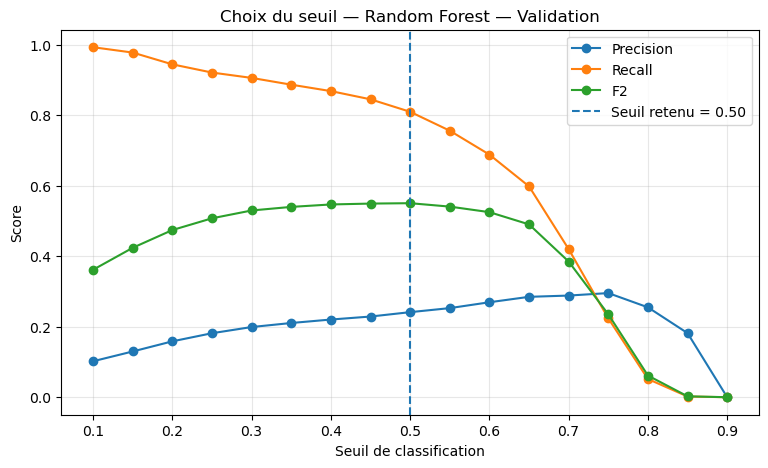

In [27]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Seuil"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)
plt.plot(
    threshold_results["Seuil"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)
plt.plot(
    threshold_results["Seuil"],
    threshold_results["F2"],
    marker="o",
    label="F2"
)

plt.axvline(best_threshold, linestyle="--", label=f"Seuil retenu = {best_threshold:.2f}")
plt.xlabel("Seuil de classification")
plt.ylabel("Score")
plt.title(f"Choix du seuil — {best_model_name} — Validation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 15. Évaluation finale sur le Test — 2022 à 2024

Nous pouvons maintenant utiliser le Test.

À partir de ce point :

- le modèle est déjà choisi ;
- ses hyperparamètres sont déjà choisis ;
- le seuil est déjà choisi.

Le Test sert uniquement à mesurer la capacité de généralisation finale sur une période plus récente.

**Il ne faut plus modifier le modèle en fonction du résultat du Test**, sinon le Test deviendrait à son tour un jeu de validation.

,Modèle,Precision,Recall,F1,PR-AUC,ROC-AUC,Balanced Accuracy
0,Random Forest,0.215,0.828,0.341,0.249,0.825,0.771


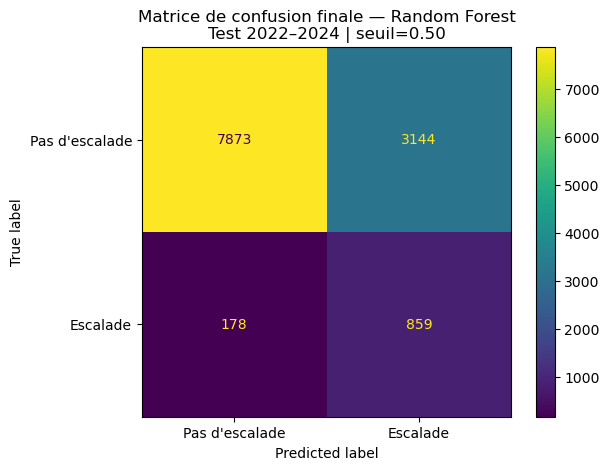

In [28]:
test_proba_final = best_model.predict_proba(X_test)[:, 1]

final_test_result = pd.DataFrame([
    evaluate_model(
        best_model_name,
        y_test,
        test_proba_final,
        threshold=best_threshold
    )
])

display(final_test_result.round(3))

test_pred_final = (test_proba_final >= best_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred_final,
    display_labels=["Pas d'escalade", "Escalade"],
    values_format="d"
)
plt.title(
    f"Matrice de confusion finale — {best_model_name}\n"
    f"Test 2022–2024 | seuil={best_threshold:.2f}"
)
plt.show()

## 16. Interpréter le résultat final

Pour interpréter le modèle, ne regardez pas une seule métrique.

### Questions à poser

1. **Recall** : quelle proportion des escalades réelles est détectée ?
2. **Precision** : quelle proportion des alertes émises est correcte ?
3. **PR-AUC** : le modèle classe-t-il globalement les observations positives mieux que la baseline ?
4. **F1 / F2** : le compromis entre détection et fausses alertes est-il acceptable ?
5. **Balanced Accuracy** : le modèle fonctionne-t-il raisonnablement sur les deux classes ?
6. **Matrice de confusion** : combien d'escalades sont réellement manquées ?

Une baisse entre Validation et Test n'est pas automatiquement un échec : elle peut signaler que les années récentes sont plus difficiles à généraliser. L'importance est de quantifier cette baisse et de ne pas la masquer par un nouveau tuning sur le Test.

# 17. Importance des features et hypothèses H1–H5

Nous utilisons la **Permutation Importance** sur la Validation.

Principe : une feature est mélangée aléatoirement. Si la PR-AUC diminue fortement, cela suggère que le modèle dépend de cette information pour ses prédictions.

Cette méthode permet d'évaluer les **features originales**, même lorsqu'elles sont ensuite transformées dans le pipeline.

Attention : l'importance prédictive n'est pas une preuve de causalité.

In [29]:
perm = permutation_importance(
    best_model,
    X_val,
    y_val,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance = (
    pd.DataFrame({
        "Feature": FEATURES,
        "Importance moyenne": perm.importances_mean,
        "Écart-type": perm.importances_std
    })
    .sort_values("Importance moyenne", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.round(4))

,Feature,Importance moyenne,Écart-type
0,applied,0.0110,0.0038
1,applied_lag1,0.0076,0.0043
2,applied_lag2,0.0025,0.0015
3,origin_applied_total_t,0.0024,0.0005
4,acceleration,0.0019,0.0013
5,asylum_applied_total_t,0.0019,0.0017
6,segment_share_asylum_t,0.0017,0.0032
7,growth_past_1,0.0012,0.0012
8,coo_name,0.0011,0.0008
9,idmc_total_origin_lag1,0.0005,0.0010


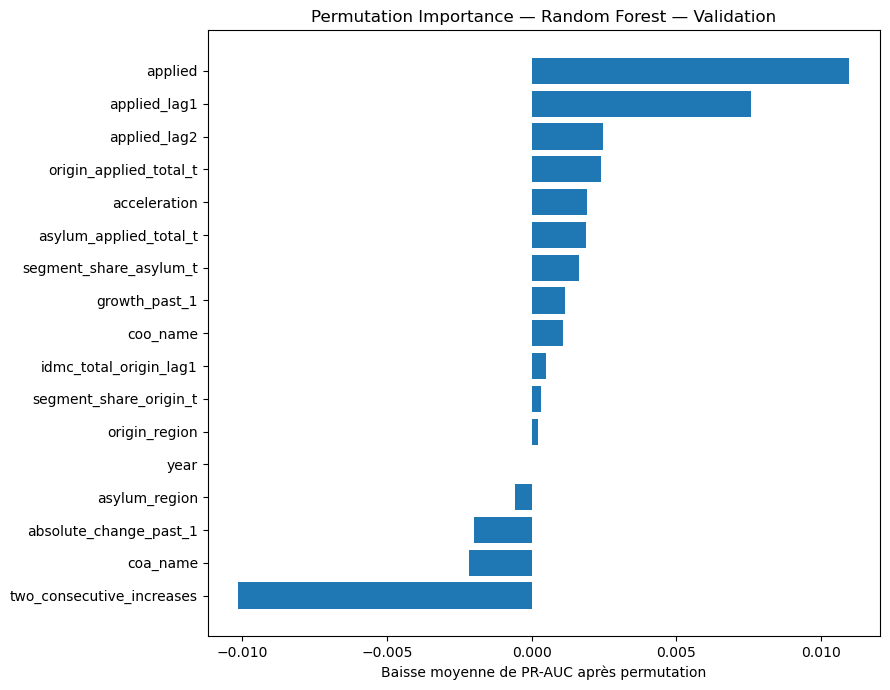

In [30]:
plot_importance = feature_importance.sort_values(
    "Importance moyenne",
    ascending=True
)

plt.figure(figsize=(9, 7))
plt.barh(
    plot_importance["Feature"],
    plot_importance["Importance moyenne"]
)
plt.xlabel("Baisse moyenne de PR-AUC après permutation")
plt.title(f"Permutation Importance — {best_model_name} — Validation")
plt.tight_layout()
plt.show()

## 18. Retour sur les hypothèses issues de l'EDA

Les hypothèses ne doivent être ni validées ni rejetées à l'avance. Elles doivent être confrontées aux résultats obtenus.

### H1 — Le volume courant apporte un signal prédictif

Observer l'importance de `applied`.

Une importance positive soutient l'idée que le volume courant contribue au modèle, mais ne signifie pas qu'il cause l'escalade.

### H2 — Les variables temporelles améliorent la détection

Examiner notamment :

- `applied_lag1` ;
- `applied_lag2` ;
- `growth_past_1` ;
- `absolute_change_past_1` ;
- `acceleration` ;
- `two_consecutive_increases`.

Si plusieurs de ces variables contribuent au modèle, cela soutient l'intérêt d'utiliser la dynamique historique plutôt que le seul volume à T.

### H3 — Les informations géographiques améliorent la discrimination

Examiner :

- `coo_name` ;
- `coa_name` ;
- `origin_region` ;
- `asylum_region`.

Une importance élevée indiquerait une utilité prédictive dans cette période historique. Elle devra toutefois être surveillée pour éviter qu'un modèle dépende excessivement d'identités géographiques spécifiques.

### H4 — IDMC apporte un signal supplémentaire

Examiner `idmc_total_origin_lag1`.

Compte tenu de son taux élevé de valeurs manquantes, une faible importance peut provenir d'un signal limité, d'une couverture insuffisante, ou des deux. La permutation importance seule ne permet pas de distinguer ces explications.

### H5 — Les modèles non linéaires représentent mieux certaines interactions

Comparer les PR-AUC de :

- Régression Logistique ;
- Random Forest ;
- XGBoost.

Si les modèles d'arbres surpassent clairement la Régression Logistique sur Validation puis conservent leur avantage sur Test, cela soutient l'hypothèse que des relations non linéaires ou des interactions apportent de l'information.

Si ce n'est pas le cas, H5 n'est pas soutenue par cette expérience.

# 19. Tableau de synthèse à compléter après exécution

Après exécution du notebook, la conclusion doit répondre clairement aux questions suivantes :

| Question | Résultat à documenter |
|---|---|
| La PR-AUC dépasse-t-elle nettement la baseline ? | À compléter |
| Quel modèle est meilleur sur Validation ? | À compléter |
| Quels sont ses meilleurs hyperparamètres ? | À compléter |
| Quel seuil a été retenu ? | À compléter |
| Quel Recall obtient-on sur Test ? | À compléter |
| Quelle Precision obtient-on sur Test ? | À compléter |
| Combien de faux négatifs restent sur Test ? | À compléter |
| Quelles features sont les plus utiles ? | À compléter |
| H1 est-elle soutenue ? | À compléter |
| H2 est-elle soutenue ? | À compléter |
| H3 est-elle soutenue ? | À compléter |
| H4 est-elle soutenue ? | À compléter |
| H5 est-elle soutenue ? | À compléter |

# Conclusion méthodologique

Le flux complet de ce notebook est :

**Dataset validé → Label → Contrôle du déséquilibre → Split temporel → Prétraitement → 4 modèles initiaux → Comparaison Validation → 2 meilleurs modèles → Tuning temporel → Nouvelle comparaison Validation → Choix du seuil → Test final → Importance des features → H1–H5**

Cette organisation permet de séparer clairement trois rôles :

- **Train** : apprendre ;
- **Validation** : choisir et optimiser ;
- **Test** : vérifier une seule fois la généralisation finale.

Le résultat du notebook devra être interprété comme un **prototype de scoring Early Warning**. Une bonne performance historique ne suffit pas, à elle seule, à démontrer qu'un système est prêt pour une utilisation opérationnelle.